https://amanxai.com/2020/07/20/next-word-prediction-model/

In [26]:
import numpy as np
from nltk.tokenize import RegexpTokenizer
from keras.models import Sequential, load_model
from keras.layers import LSTM
from keras.layers import Dense, Activation
from keras.optimizers import RMSprop
import matplotlib.pyplot as plt
import pickle 
import heapq

In [27]:
path = "1661-0.txt"
text = open(path).read().lower()
print('Length:', len(text))

Length: 581888


In [28]:
tokenizer = RegexpTokenizer(r'\w+')
words = tokenizer.tokenize(text)
words

['project',
 'gutenberg',
 's',
 'the',
 'adventures',
 'of',
 'sherlock',
 'holmes',
 'by',
 'arthur',
 'conan',
 'doyle',
 'this',
 'ebook',
 'is',
 'for',
 'the',
 'use',
 'of',
 'anyone',
 'anywhere',
 'at',
 'no',
 'cost',
 'and',
 'with',
 'almost',
 'no',
 'restrictions',
 'whatsoever',
 'you',
 'may',
 'copy',
 'it',
 'give',
 'it',
 'away',
 'or',
 're',
 'use',
 'it',
 'under',
 'the',
 'terms',
 'of',
 'the',
 'project',
 'gutenberg',
 'license',
 'included',
 'with',
 'this',
 'ebook',
 'or',
 'online',
 'at',
 'www',
 'gutenberg',
 'net',
 'title',
 'the',
 'adventures',
 'of',
 'sherlock',
 'holmes',
 'author',
 'arthur',
 'conan',
 'doyle',
 'release',
 'date',
 'november',
 '29',
 '2002',
 'ebook',
 '1661',
 'last',
 'updated',
 'may',
 '20',
 '2019',
 'language',
 'english',
 'character',
 'set',
 'encoding',
 'utf',
 '8',
 'start',
 'of',
 'this',
 'project',
 'gutenberg',
 'ebook',
 'the',
 'adventures',
 'of',
 'sherlock',
 'holmes',
 'produced',
 'by',
 'an',
 'ano

In [29]:
unique_words = np.unique(words)
unique_word_index = dict((c, i) for i, c in enumerate(unique_words))
unique_word_index

{np.str_('0'): 0,
 np.str_('000'): 1,
 np.str_('1'): 2,
 np.str_('10'): 3,
 np.str_('100'): 4,
 np.str_('1000'): 5,
 np.str_('10_s_'): 6,
 np.str_('10th'): 7,
 np.str_('11'): 8,
 np.str_('117'): 9,
 np.str_('120'): 10,
 np.str_('12_s_'): 11,
 np.str_('12th'): 12,
 np.str_('14'): 13,
 np.str_('140'): 14,
 np.str_('15'): 15,
 np.str_('150'): 16,
 np.str_('1500'): 17,
 np.str_('1661'): 18,
 np.str_('16a'): 19,
 np.str_('17'): 20,
 np.str_('1846'): 21,
 np.str_('1858'): 22,
 np.str_('1869'): 23,
 np.str_('1870'): 24,
 np.str_('1878'): 25,
 np.str_('1883'): 26,
 np.str_('1884'): 27,
 np.str_('1887'): 28,
 np.str_('1888'): 29,
 np.str_('1890'): 30,
 np.str_('19th'): 31,
 np.str_('1_s_'): 32,
 np.str_('2'): 33,
 np.str_('20'): 34,
 np.str_('200'): 35,
 np.str_('2001'): 36,
 np.str_('2002'): 37,
 np.str_('2019'): 38,
 np.str_('220'): 39,
 np.str_('221b'): 40,
 np.str_('226'): 41,
 np.str_('22nd'): 42,
 np.str_('249'): 43,
 np.str_('25'): 44,
 np.str_('250'): 45,
 np.str_('26'): 46,
 np.str_('2

In [30]:
# WORD_LENGTH = 5
# prev_words = []
# next_words = []
# for i in range(len(words) - WORD_LENGTH):
#     prev_words.append(words[i : i + WORD_LENGTH])
#     next_words.append(words[i + WORD_LENGTH])
# print(prev_words[0])
# print(next_words[0])

WORD_LENGTH = 5
prev_words = []
next_words = []
for i in range(len(words) - WORD_LENGTH):
    prev_words.append(words[i:i + WORD_LENGTH])
    next_words.append(words[i + WORD_LENGTH])
print(prev_words[0])
print(next_words[0])

['project', 'gutenberg', 's', 'the', 'adventures']
of


In [31]:
# X = np.zeros((len(prev_words), WORD_LENGTH, len(unique_words)), dtype=bool)
# Y = np.zeros((len(next_words), len(unique_words)), dtype=bool)

# for i, each_words in enumerate(prev_words):
#     for j, each_word in enumerate(each_words):
#         X[i, j, unique_words_index[each_word]] = 1
#     Y[i, unique_words_index[next_words[i]]] = 1

# print(len(X[0][0]))

X = np.zeros((len(prev_words), WORD_LENGTH, len(unique_words)), dtype=bool)
Y = np.zeros((len(next_words), len(unique_words)), dtype=bool)
for i, each_words in enumerate(prev_words):
    for j, each_word in enumerate(each_words):
        X[i, j, unique_word_index[each_word]] = 1
    Y[i, unique_word_index[next_words[i]]] = 1

Building Recurrent Neural Network using LSTM Model

In [32]:
print(X[0][0])


[False False False ... False False False]


In [33]:
# model = Sequential()
# model.add(LSTM(128, input_shape=(WORD_LENGTH, len(unique_words))))
# model.add(Dense(len(unique_words)))
# model.add(Activation('softmax'))

model = Sequential()
model.add(LSTM(128, input_shape=(WORD_LENGTH, len(unique_words))))
model.add(Dense(len(unique_words)))
model.add(Activation('softmax'))

In [34]:
# optimizer = RMSprop(learning_rate=0.01)
# model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# history = model.fit(X,Y, validation_split=0.05, batch_size=128, epochs=20, shuffle=True).history
    
optimizer = RMSprop(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(X, Y, validation_split=0.05, batch_size=128, epochs=2, shuffle=True).history

Epoch 1/2
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.0762 - loss: 6.2722 - val_accuracy: 0.0752 - val_loss: 6.9695
Epoch 2/2
811/811 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1200 - loss: 5.6998 - val_accuracy: 0.0974 - val_loss: 6.6853


In [35]:
# model.save('keras_next_word_model.h5')
# pickle.dump(history, open("history.p", "wb"))
# model = load_model('keras_next_word_model.h5')
# history = pickle.load(open("history.p", "rb"))
# history
model.save('keras_next_word_model.h5')
pickle.dump(history, open("history.p", "wb"))
model = load_model('keras_next_word_model.h5')
history = pickle.load(open("history.p", "rb"))
history

{'accuracy': [0.07617652416229248, 0.1199510395526886],
 'loss': [6.27217960357666, 5.699815273284912],
 'val_accuracy': [0.07524716109037399, 0.09740021824836731],
 'val_loss': [6.969545364379883, 6.6852617263793945]}

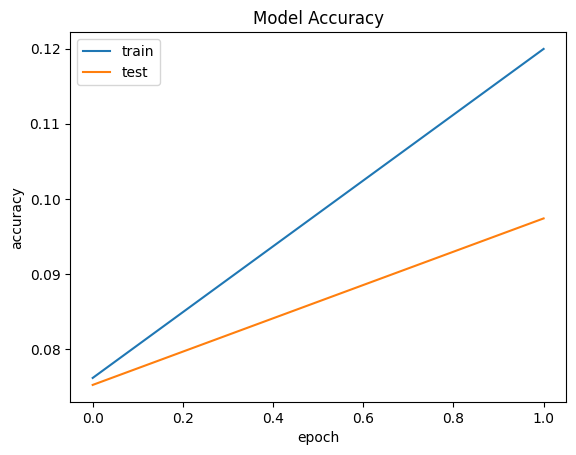

In [36]:
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

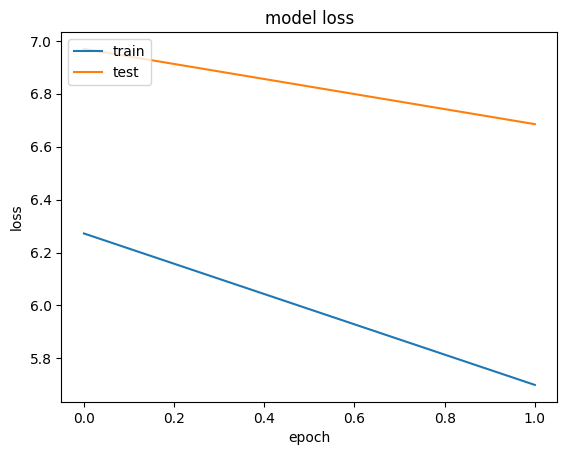

In [37]:
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')


In [39]:
def prepare_input(text):
    x = np.zeros((1, WORD_LENGTH, len(unique_words)))
    for t, word in enumerate(text.split()):
        print(word)
        x[0, t, unique_word_index[word]] = 1
    return x
prepare_input("It is not a lack".lower())

it
is
not
a
lack


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(1, 5, 8201))

In [ ]:
def samples(pred, top_n=3):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds)
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return heapq.nlargest(top_n, range(len(preds)), preds.take)

def predict_completion(text):
    original_text = text
    generated = text
    completion = ''
    while True:
        x = prepare_input(text)
        preds = model.predict(x, verbose=0)[0]
        next_index = samples(preds, top_n=1)[0]
        next_char = indices_char[next_index]
        text = text[1:] + next_char
        completion += next_char
        
        if len(original_text + completion) + 2 > len(original_text) and next_char == ' ':
            return completion
        
def predict_completions(text, n=3):
    x = prepare_input(text)
    preds = model.predict(x, verbose=0)[0]
    next_indices = samples(preds, n)
    return [indices_char[idx] + predict_completion(text[1:] + indices_char[idx]) for idx in next_indices]